In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [20]:
#set path + read into dataframe
path = r'../rotterdam_dataset_06.xlsx'
rd = pd.read_excel(path)

#rename for easiness
rd = rd.rename(columns = {'Arrival_Date': 'arrival_date','Vessel_ID':'vessel_id','Vessel_Type':'vessel_type', 'Cargo_tons':'cargo_tons',
                         'Berth_Time_hr':'berth_time_hr'})

# + seaborn style
sns.set_theme(style = 'darkgrid')
palette = sns.color_palette('colorblind')
sns.set_palette('colorblind')

## Arrival Rates (month/day)

In [119]:
#setting up new cols for easy filtering later
rd['year_month_day'] = rd['arrival_date'].dt.strftime('%Y-%m-%d')
rd['year_month'] = rd['arrival_date'].dt.strftime('%Y-%m')
rd['year'] = rd['arrival_date'].dt.strftime('%Y')
rd['month_day'] = rd['arrival_date'].dt.strftime('%m-%d')

#setup grouping for analysis
year_month_count = rd['year_month'].groupby(rd['year_month']).count()
year_month_day_count = rd['year_month_day'].groupby(rd['year_month_day']).count()

In [70]:
#avg, median, std PER MONTH
avg_arrival_month = year_month_count.mean()
med_arrival_month = year_month_count.median()
std_arrival_month = year_month_count.std()
print(avg_arrival_month, med_arrival_month, std_arrival_month)

#max,min
max_arrival_month = year_month_count.max()
print(max_arrival_month)
min_arrival_month = year_month_count.min()
print(min_arrival_month)

#check where min/max are
#print(rd['year_month'].groupby(rd['year_month']).count().sort_values(ascending = True))


545.1944444444445 518.0 78.0204440037333
689
420


In [82]:
#outliers
q3_month = year_month_count.quantile(.75)
q1_month = year_month_count.quantile(.25)

large_outlier_month = year_month_count[year_month_count > q3_month]
print(large_outlier_month)

small_outlier_month = year_month_count[year_month_count < q1_month]
print(small_outlier_month)

year_month
2022-05    649
2022-07    647
2022-08    689
2023-05    663
2023-06    629
2023-07    646
2023-08    680
2024-05    654
2024-07    658
Name: year_month, dtype: int64
year_month
2022-01    460
2022-02    420
2022-03    478
2022-12    455
2023-02    471
2023-12    473
2024-01    478
2024-02    433
2024-12    450
Name: year_month, dtype: int64


In [90]:
#avg, median, variance, and std PER DAY
avg_arrival_day = year_month_day_count.mean()
med_arrival_day = year_month_day_count.median()
var_arrival_day = year_month_day_count.var()
std_arrival_day = year_month_day_count.std()
print(avg_arrival_day, med_arrival_day, var_arrival_day, std_arrival_day)

#max, min
max_arrival_day = year_month_day_count.max()
min_arrival_day = year_month_day_count.min()
print(f'max = {max_arrival_day}, min = {min_arrival_day}')

#check where min/max are + other suspicious vals
print(year_month_day_count.sort_values(ascending = True))

17.907846715328468 18.0 23.358623304336238 4.8330759671596555
max = 35, min = 4
year_month_day
2023-10-23     4
2023-11-13     6
2022-12-24     6
2022-09-22     7
2024-09-29     7
              ..
2022-07-27    32
2022-08-08    32
2023-07-24    33
2024-07-08    33
2022-05-25    35
Name: year_month_day, Length: 1096, dtype: int64


In [92]:
#outliers
q3_month = year_month_day_count.quantile(.75)
q1_month = year_month_day_count.quantile(.25)
print(q3_month, q1_month)

large_outlier_day = year_month_day_count[year_month_day_count > q3_month]
print(large_outlier_day.describe())
print(large_outlier_day)

small_outlier_day = year_month_day_count[year_month_day_count < q1_month]
print(small_outlier_day.describe())
print(small_outlier_day)

21.0 14.0
count    248.000000
mean      24.673387
std        2.716380
min       22.000000
25%       23.000000
50%       24.000000
75%       26.000000
max       35.000000
Name: year_month_day, dtype: float64
year_month_day
2022-01-14    28
2022-01-31    22
2022-02-28    22
2022-03-14    23
2022-04-05    23
              ..
2024-11-02    29
2024-11-12    23
2024-11-13    22
2024-11-20    23
2024-11-25    24
Name: year_month_day, Length: 248, dtype: int64
count    210.000000
mean      11.509524
std        1.578081
min        4.000000
25%       11.000000
50%       12.000000
75%       13.000000
max       13.000000
Name: year_month_day, dtype: float64
year_month_day
2022-01-01    10
2022-01-03    13
2022-01-11    11
2022-01-12    13
2022-01-17    12
              ..
2024-12-23    10
2024-12-24    12
2024-12-26    11
2024-12-28    11
2024-12-29    13
Name: year_month_day, Length: 210, dtype: int64


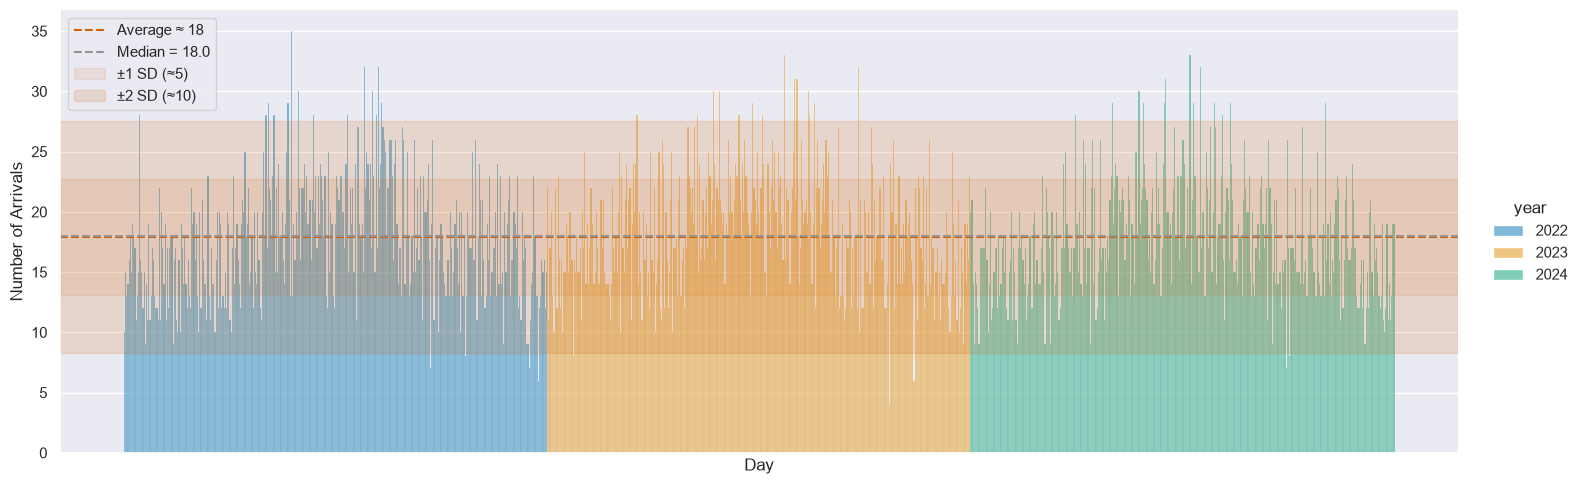

In [40]:
#histogram of per day vessel calls
h = sns.displot(data = rd, x = 'year_month_day', hue = 'year', aspect = 3, kind = 'hist')

#adding a mean line
h.ax.axhline(avg_arrival_day, color = palette[3], linestyle = '--', label = f'Average ≈ {round(avg_arrival_day)}')

#adding a median line => get rid of this if too much
h.ax.axhline(med_arrival_day, color = palette[7], linestyle = '--', label = f'Median = {med_arrival_day}')

#std shading
h.ax.axhspan(avg_arrival_day - std_arrival_day, avg_arrival_day + std_arrival_day, color = palette[3],
             alpha=0.1, label=f'±1 SD (≈{round(std_arrival_day)})')

h.ax.axhspan(avg_arrival_day - 2*std_arrival_day, avg_arrival_day + 2*std_arrival_day, color = palette[3],
             alpha=0.15, label=f'±2 SD (≈{round(2*std_arrival_day)})')

h.ax.legend()
h.ax.set_xticks([])
h.set_axis_labels('Day', 'Number of Arrivals')
h.tight_layout()

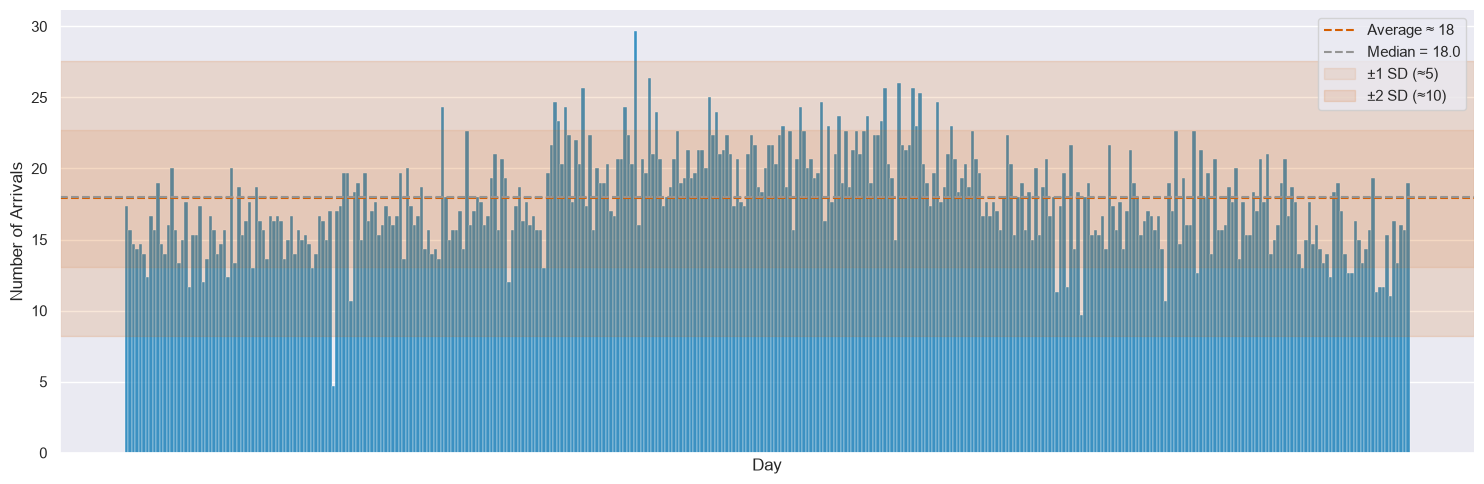

In [124]:
#histogram of per day vessel calls
h = sns.displot(data = rd.sort_values('month_day').assign(w = 1/3), x = 'month_day',
                weights = 'w', aspect = 3, kind = 'hist')

#adding a mean line
h.ax.axhline(avg_arrival_day, color = palette[3], linestyle = '--', label = f'Average ≈ {round(avg_arrival_day)}')

#adding a median line => get rid of this if too much
h.ax.axhline(med_arrival_day, color = palette[7], linestyle = '--', label = f'Median = {med_arrival_day}')

#std shading
h.ax.axhspan(avg_arrival_day - std_arrival_day, avg_arrival_day + std_arrival_day, color = palette[3],
             alpha=0.1, label=f'±1 SD (≈{round(std_arrival_day)})')

h.ax.axhspan(avg_arrival_day - 2*std_arrival_day, avg_arrival_day + 2*std_arrival_day, color = palette[3],
             alpha=0.15, label=f'±2 SD (≈{round(2*std_arrival_day)})')

h.ax.legend()
h.ax.set_xticks([])
h.set_axis_labels('Day', 'Number of Arrivals')
h.tight_layout()

## Arrival rates + vessel types

In [121]:
#filter for vessel types
print(rd['vessel_type'].unique())

#first filter for vessel type, then group by for stats x3
container = rd[rd['vessel_type'] == 'Container']
container_day_count = container['year_month_day'].groupby(container['year_month_day']).count()

tanker = rd[rd['vessel_type'] == 'Tanker']
tanker_day_count = tanker['year_month_day'].groupby(tanker['year_month_day']).count()

bulk = rd[rd['vessel_type'] == 'Bulk']
bulk_day_count = bulk['year_month_day'].groupby(bulk['year_month_day']).count()


<StringArray>
['Container', 'Tanker', 'Bulk']
Length: 3, dtype: str


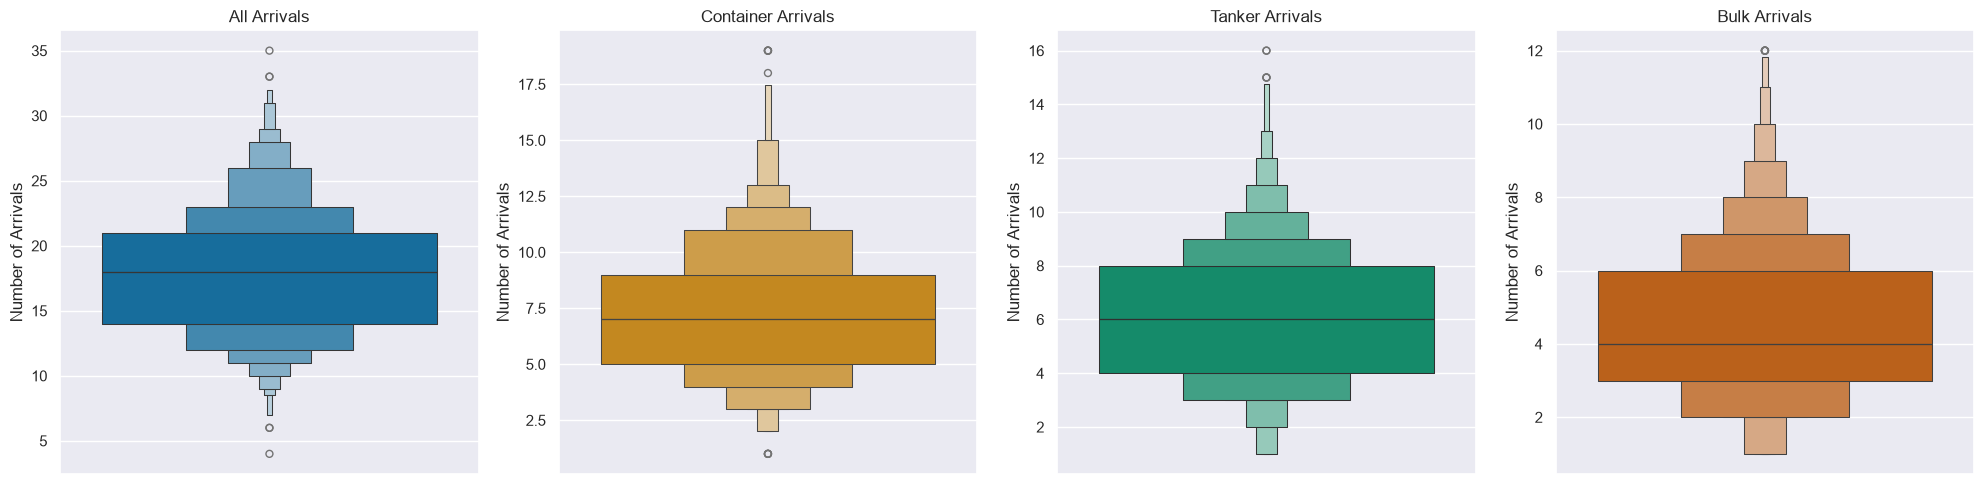

In [116]:
#plots next to each other despite diff scale b/c need space on report
f, ax = plt.subplots(1, 4, figsize = (20, 5))

#boxenplots good for large datasets
sns.boxenplot(y = year_month_day_count, ax = ax[0], color = palette[0])
ax[0].set_title('All Arrivals')
ax[0].set_ylabel('Number of Arrivals')

sns.boxenplot(y = container_day_count, ax = ax[1], color = palette[1])
ax[1].set_title('Container Arrivals')
ax[1].set_ylabel('Number of Arrivals')

sns.boxenplot(y = tanker_day_count, ax = ax[2], color = palette[2])
ax[2].set_title('Tanker Arrivals')
ax[2].set_ylabel('Number of Arrivals')

sns.boxenplot(y = bulk_day_count, ax = ax[3], color = palette[3])
ax[3].set_title('Bulk Arrivals')
ax[3].set_ylabel('Number of Arrivals')

#save/layout
plt.tight_layout()
plt.savefig('figures/arrivalsbox.jpeg', bbox_inches='tight')
plt.show()

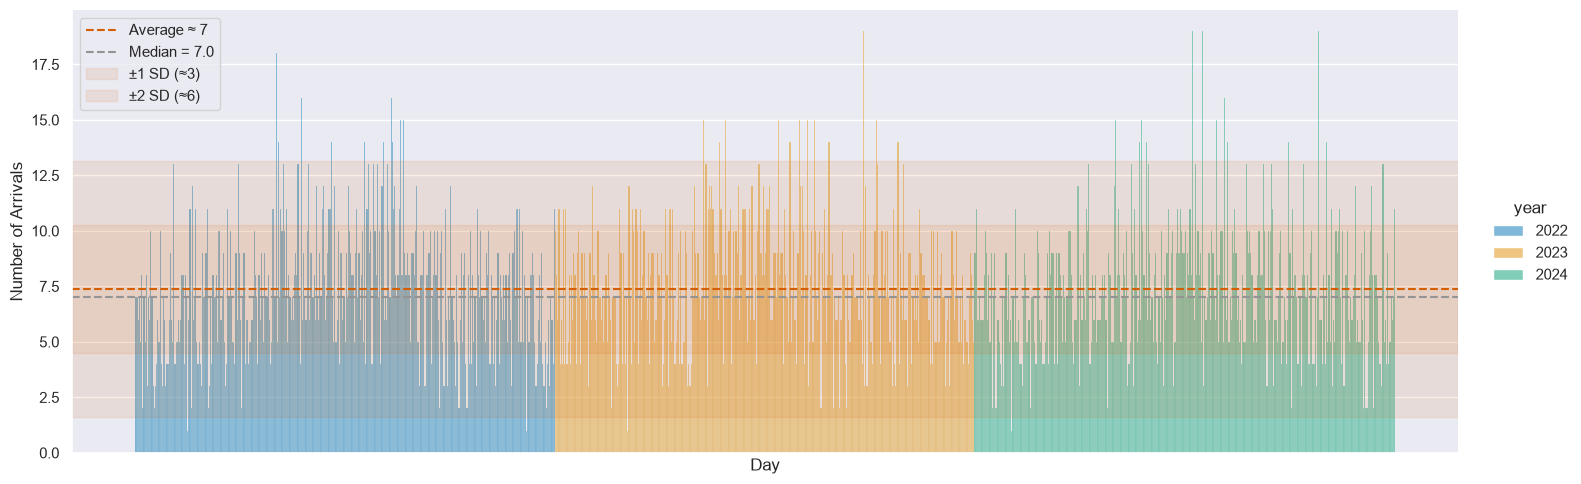

In [115]:
#container type arrivals
h = sns.displot(data = container, x = 'year_month_day', hue = 'year', aspect = 3, kind = 'hist')

#adding a mean line
mean_container_day = container_day_count.mean()
h.ax.axhline(mean_container_day, color = palette[3], linestyle = '--', label = f'Average ≈ {round(mean_container_day)}')

#adding a median line => get rid of this if too much
h.ax.axhline(container_day_count.median(), color = palette[7], linestyle = '--', label = f'Median = {container_day_count.median()}')

#std shading
std_container_day = container_day_count.std()
h.ax.axhspan(mean_container_day - std_container_day, mean_container_day + std_container_day, color = palette[3],
             alpha=0.1, label=f'±1 SD (≈{round(std_container_day)})')

h.ax.axhspan(mean_container_day - 2*std_container_day, mean_container_day + 2*std_container_day, color = palette[3],
             alpha=0.1, label=f'±2 SD (≈{round(2*std_container_day)})')

h.ax.legend()
h.ax.set_xticks([])
h.set_axis_labels('Day', 'Number of Arrivals')
h.tight_layout()

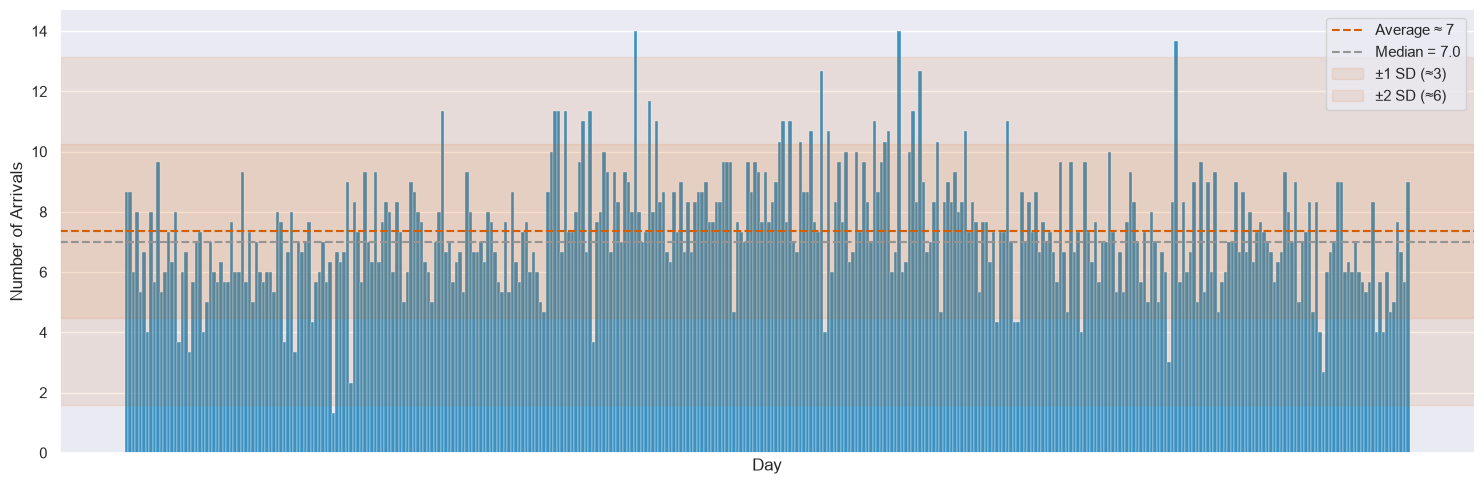

In [123]:
h = sns.displot(data = container.sort_values('month_day').assign(w = 1/3), x = 'month_day',
                weights = 'w', aspect = 3, kind = 'hist')

#adding a mean line
mean_container_day = container_day_count.mean()
h.ax.axhline(mean_container_day, color = palette[3], linestyle = '--', label = f'Average ≈ {round(mean_container_day)}')

#adding a median line => get rid of this if too much
h.ax.axhline(container_day_count.median(), color = palette[7], linestyle = '--', label = f'Median = {container_day_count.median()}')

#std shading
std_container_day = container_day_count.std()
h.ax.axhspan(mean_container_day - std_container_day, mean_container_day + std_container_day, color = palette[3],
             alpha=0.1, label=f'±1 SD (≈{round(std_container_day)})')

h.ax.axhspan(mean_container_day - 2*std_container_day, mean_container_day + 2*std_container_day, color = palette[3],
             alpha=0.1, label=f'±2 SD (≈{round(2*std_container_day)})')

h.ax.legend()
h.ax.set_xticks([])
h.set_axis_labels('Day', 'Number of Arrivals')
h.tight_layout()